# Title- Predicting Individual Medical Insurance Charges Using Regression

### CSE 4114-Introduction to Data Science Lab
###Course Code: CSE 4114  
###Project Type: Regression  


**Dataset:** Medical Cost Personal Dataset


**Problem Type:** Regression

**Student Name 1:** [MD. NASIRUDDIN SHAEL]

**Student ID:** [11230121199]

**Student Name 2:** [MD. ABU BAKAR SIAM]

**Student ID:** [11230121182]

**Instructor:** [MD. HASIBUL ISLAM]


## Project Overview

This project develops a machine learning regression system to predict individual medical insurance charges using demographic, lifestyle, and regional information.

The project follows the complete Data Science workflow required for the lab:
1. Problem Statement and Objectives
2. Dataset Description and Source
3. Data Collection
4. Data Cleaning and Preprocessing
5. Exploratory Data Analysis
6. Data Visualization
7. Feature Engineering
8. Feature Selection
9. Machine Learning Model Development
10. Model Evaluation and Comparison
11. Results, Discussion, and Conclusion

## 1. Problem Statement and Project Objectives

### 1.1 Problem Statement

Health insurance providers need to estimate the yearly medical expenses of a policyholder before a policy is issued, so that premiums can be set fairly and profitably. Charges vary widely from one person to another, and the relationship between simple demographic and lifestyle attributes (age, body mass index, smoking status, number of dependents, sex, and region of residence) and the resulting medical cost is not obvious by inspection. This project builds a regression based system that predicts the annual medical insurance charges billed to an individual using only a small set of easily collected attributes.

### 1.2 Objectives

1. Explore and understand the structure, distribution, and relationships present in the Medical Cost Personal Dataset.
2. Clean and preprocess the data, handling missing values, duplicate records, and outliers.
3. Perform exploratory data analysis supported by visualizations to surface the main cost drivers.
4. Engineer new features and encode categorical variables to improve model quality.
5. Train and compare several regression models for predicting medical charges.
6. Evaluate the trained models using appropriate regression metrics and select the best performing model.
7. Summarize findings, discuss limitations, and draw conclusions relevant to insurance pricing.


## 2. Dataset Description and Source

### 2.1 Source

The Medical Cost Personal Dataset was originally published as a companion dataset for the book *Machine Learning with R* by Brett Lantz, and is widely mirrored for public use, including on Kaggle under the title "Medical Cost Personal Datasets". The copy used in this project was retrieved from a public GitHub mirror of the dataset (`insurance.csv`).

### 2.2 Description

The dataset contains 1338 records describing individuals covered by a health insurance plan in the United States, along with the yearly medical charges billed to them. There are seven columns in total:

| Column | Type | Description |
|---|---|---|
| age | Numeric | Age of the primary beneficiary in years |
| sex | Categorical | Biological sex of the insurance contractor (female, male) |
| bmi | Numeric | Body mass index, a measure of body fat based on height and weight |
| children | Numeric | Number of children or dependents covered by the insurance plan |
| smoker | Categorical | Smoking status of the beneficiary (yes, no) |
| region | Categorical | Residential area in the United States (northeast, northwest, southeast, southwest) |
| charges | Numeric (Target) | Individual medical costs billed by health insurance, in US dollars |

The target variable for this regression task is `charges`.


## 3. Data Collection

The dataset is already collected and distributed as a single flat CSV file, so no additional scraping or survey based collection was needed for this project. The file was downloaded programmatically and loaded directly into a pandas DataFrame for processing.


In [3]:
# Import core libraries
import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error
)

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    XGBRegressor = None
    print("XGBoost is not installed. The remaining models will still run.")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Create the output directory before any figure is saved.
Path("figures").mkdir(parents=True, exist_ok=True)

print("Environment initialized successfully.")
print("XGBoost available:", XGBOOST_AVAILABLE)

Environment initialized successfully.
XGBoost available: True


In [4]:
from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully!")

Mounted at /content/drive
Google Drive mounted successfully!


In [5]:
LOCAL_FILE = "/content/drive/MyDrive/insurance.csv"
DATA_URL = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"

if os.path.exists(LOCAL_FILE):
    df = pd.read_csv(LOCAL_FILE)
    print(f"Loaded local dataset: {LOCAL_FILE}")
else:
    try:
        df = pd.read_csv(DATA_URL)
        print("Dataset downloaded successfully.")
    except Exception as e:
        print("Automatic download failed.")
        print("Please upload insurance.csv using the next cell.")
        df = None
        print("Error:", e)

if df is not None:
    print("Shape of dataset:", df.shape)
    display(df.head())

Loaded local dataset: /content/drive/MyDrive/insurance.csv
Shape of dataset: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
# Standardize column names and validate the expected dataset structure
df.columns = df.columns.str.strip().str.lower()

expected_columns = {"age", "sex", "bmi", "children", "smoker", "region", "charges"}
missing_expected = expected_columns - set(df.columns)

if missing_expected:
    raise ValueError(
        f"Dataset is missing expected columns: {sorted(missing_expected)}. "
        f"Found columns: {df.columns.tolist()}"
    )

print("Validated columns:", df.columns.tolist())

Validated columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


## 4. Data Cleaning and Preprocessing

### 4.1 Handling Missing Values


In [9]:
# Check for missing values in every column
missing_summary = df.isnull().sum().to_frame('missing_count')
missing_summary['missing_percent'] = (missing_summary['missing_count'] / len(df) * 100).round(2)
missing_summary


,missing_count,missing_percent
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0


The missing-value table above is generated from the actual dataset. If missing values are present, the modeling pipeline should handle them using an appropriate imputation strategy. If no missing values are present, no imputation is needed for this dataset.

### 4.2 Removing Duplicates


In [10]:
duplicate_count = df.duplicated().sum()
print(f'Number of fully duplicated rows: {duplicate_count}')

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Shape after removing duplicates: {df.shape}')
else:
    print('No duplicate rows found; shape remains:', df.shape)


Number of fully duplicated rows: 1
Shape after removing duplicates: (1337, 7)


### 4.3 Handling Outliers

The two continuous predictor columns most likely to contain extreme values are `bmi` and `charges`. Outliers are examined using box plots and the interquartile range (IQR) method rather than removed outright, since in this domain a very high BMI or a very high medical charge for a smoker is a genuine and informative data point rather than a data entry error.


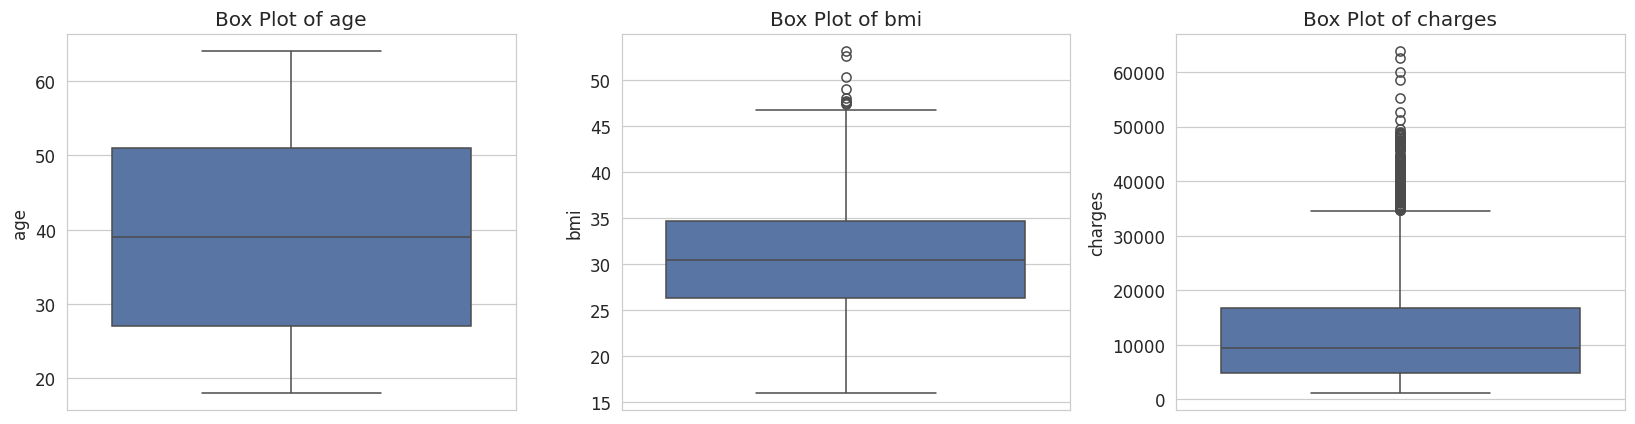

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['age', 'bmi', 'charges']):
    sns.boxplot(y=df[col], ax=ax, color='#4C72B0')
    ax.set_title(f'Box Plot of {col}')
plt.tight_layout()
plt.savefig('figures/boxplots_raw.png', bbox_inches='tight')
plt.show()


In [12]:
def iqr_outlier_report(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    print(f'{column}: lower bound = {lower:.2f}, upper bound = {upper:.2f}, outlier count = {len(outliers)}')
    return outliers

bmi_outliers = iqr_outlier_report(df, 'bmi')
charge_outliers = iqr_outlier_report(df, 'charges')


bmi: lower bound = 13.67, upper bound = 47.32, outlier count = 9
charges: lower bound = -13120.72, upper bound = 34524.78, outlier count = 139


The box plots identify statistical outliers using the IQR rule. An IQR outlier is not automatically a data error. Medical charges can legitimately contain extreme values, so the target variable is not deleted or capped.

For this project, BMI is capped at the IQR bounds as a preprocessing experiment. The effect of this choice should be interpreted carefully because capping can remove legitimate extremes. The raw target `charges` is retained, while a log-transformed target is also evaluated for selected models.

In [13]:
def cap_outliers(data, column):
    data = data.copy()
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    data[column] = np.clip(data[column], lower, upper)
    return data

df = cap_outliers(df, "bmi")
print("BMI summary after IQR capping:")
display(df["bmi"].describe())

BMI summary after IQR capping:


,bmi
count,1337.000000
mean,30.650247
std,6.059655
min,15.960000
25%,26.290000
50%,30.400000
75%,34.700000
max,47.315000


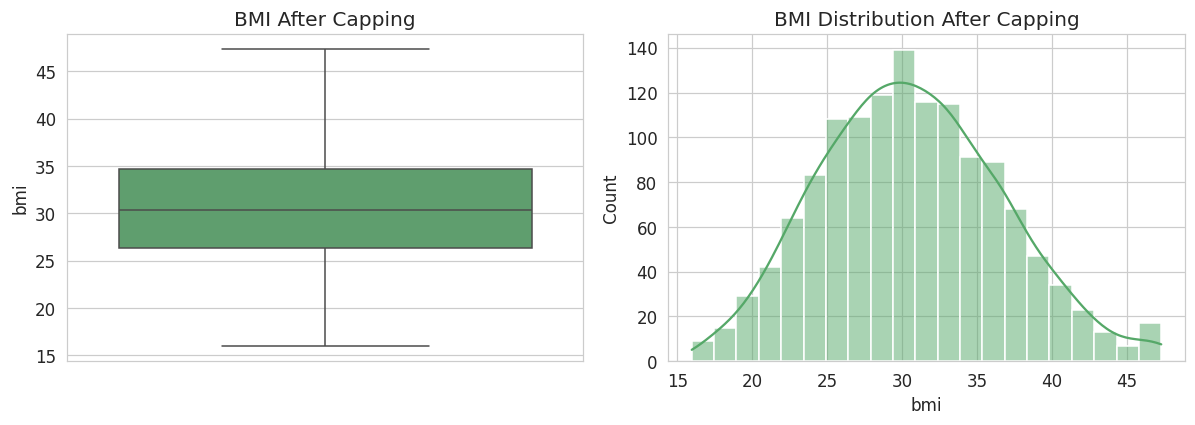

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=df['bmi'], ax=axes[0], color='#55A868')
axes[0].set_title('BMI After Capping')
sns.histplot(df['bmi'], kde=True, ax=axes[1], color='#55A868')
axes[1].set_title('BMI Distribution After Capping')
plt.tight_layout()
plt.savefig('figures/bmi_after_capping.png', bbox_inches='tight')
plt.show()


## 5. Exploratory Data Analysis (EDA)

### 5.1 Target Variable Distribution


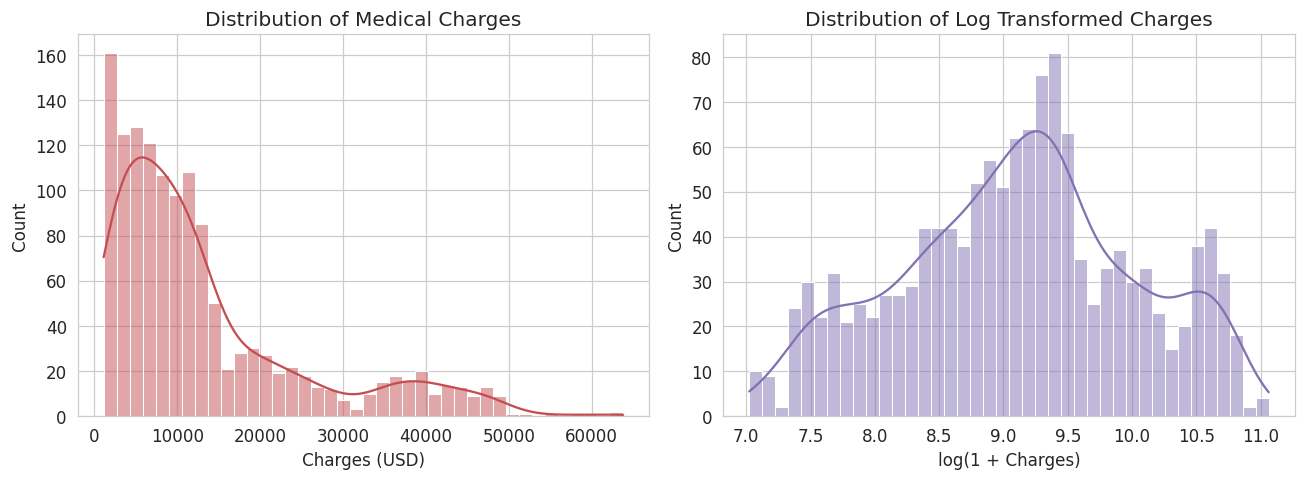

Average Age: 39.22 years
Average BMI: 30.65
Average Children: 1.1
Average Charges: 13279.12 USD
Skewness of raw charges: 1.515
Skewness of log charges: -0.09


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(
    df['charges'],
    kde=True,
    ax=axes[0],
    color='#C44E52',
    bins=40
)

axes[0].set_title('Distribution of Medical Charges')
axes[0].set_xlabel('Charges (USD)')

sns.histplot(
    np.log1p(df['charges']),
    kde=True,
    ax=axes[1],
    color='#8172B2',
    bins=40
)

axes[1].set_title('Distribution of Log Transformed Charges')
axes[1].set_xlabel('log(1 + Charges)')

plt.tight_layout()

plt.savefig(
    'figures/target_distribution.png',
    bbox_inches='tight'
)

plt.show()

print("Average Age:", round(df['age'].mean(), 2), "years")
print("Average BMI:", round(df['bmi'].mean(), 2))
print("Average Children:", round(df['children'].mean(), 2))
print("Average Charges:", round(df['charges'].mean(), 2), "USD")

print("Skewness of raw charges:", round(df['charges'].skew(), 3))
print("Skewness of log charges:", round(np.log1p(df['charges']).skew(), 3))

The plots above allow us to compare the distribution of raw medical charges with the log-transformed target. The printed skewness values should be used to describe how much the transformation changes the distribution in this actual run.

### 5.2 Categorical Feature Relationships

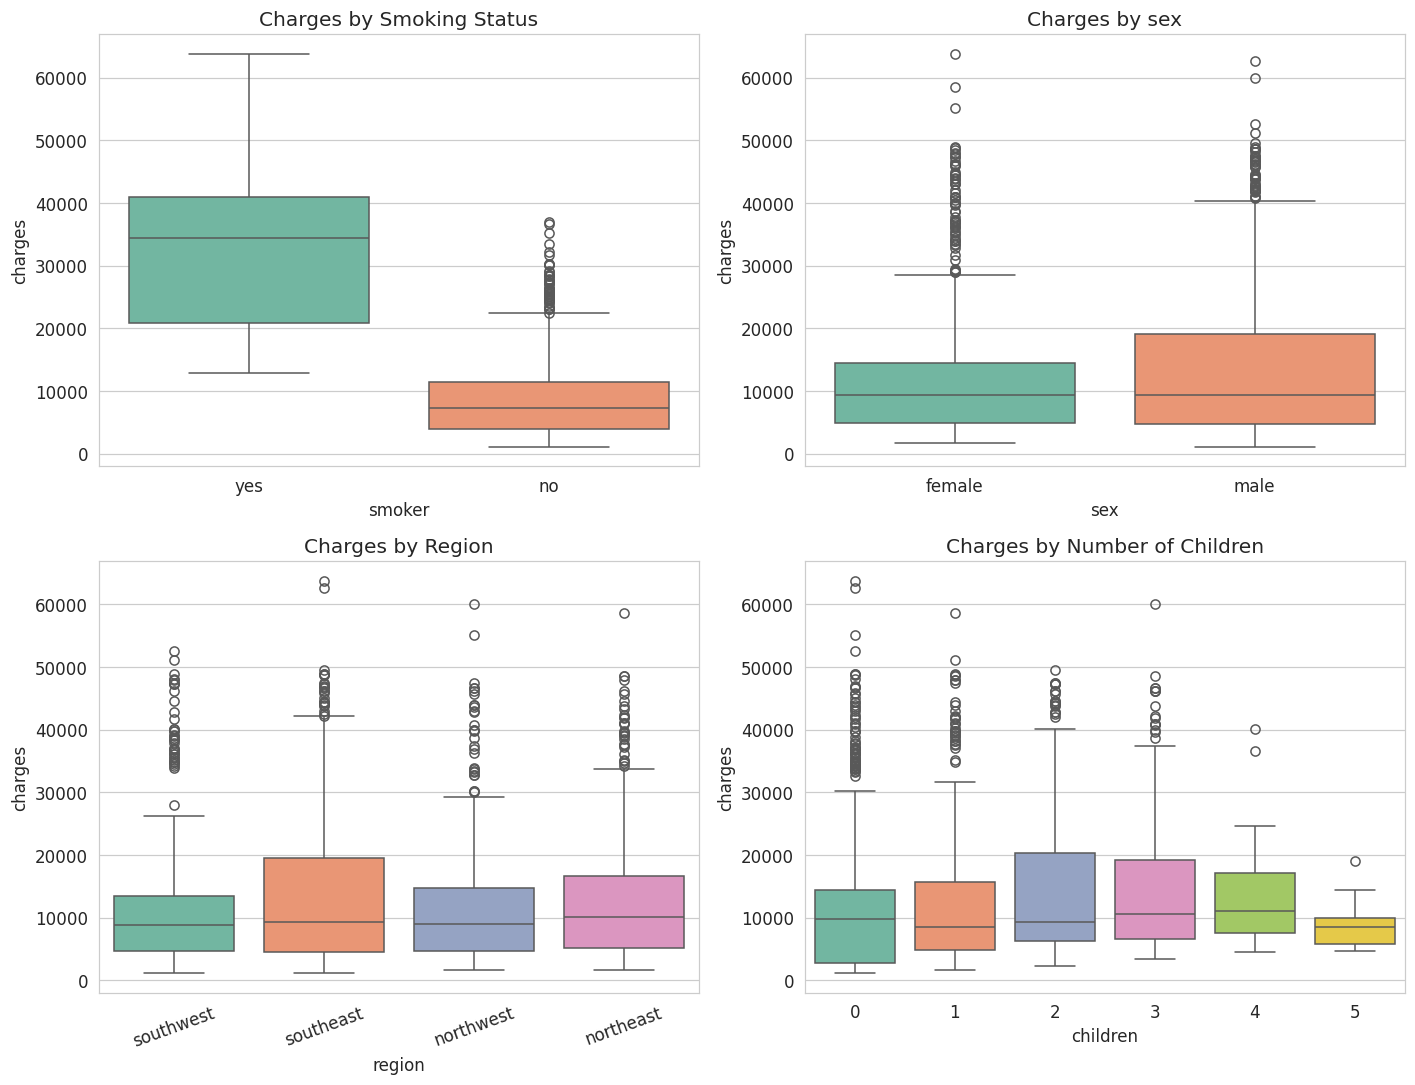

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.boxplot(data=df, x='smoker', y='charges', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Charges by Smoking Status')

sns.boxplot(data=df, x='sex', y='charges', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Charges by sex')

sns.boxplot(data=df, x='region', y='charges', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Charges by Region')
axes[1, 0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x='children', y='charges', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Charges by Number of Children')

plt.tight_layout()
plt.savefig('figures/categorical_relationships.png', bbox_inches='tight')
plt.show()


The box plots above should be interpreted from the observed distributions rather than from a pre-written conclusion. In particular, compare the central tendency, spread, and overlap of charges across smoking status, sex, region, and number of children.

### 5.3 Numeric Feature Relationships

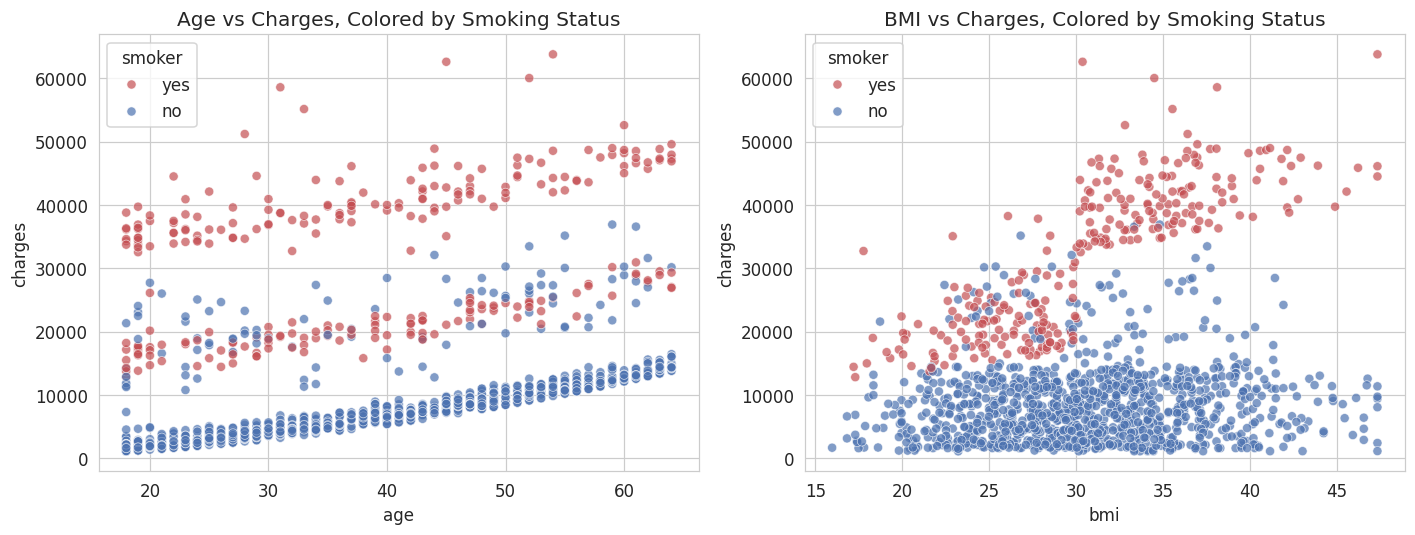

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.7, ax=axes[0], palette={'yes': '#C44E52', 'no': '#4C72B0'})
axes[0].set_title('Age vs Charges, Colored by Smoking Status')

sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.7, ax=axes[1], palette={'yes': '#C44E52', 'no': '#4C72B0'})
axes[1].set_title('BMI vs Charges, Colored by Smoking Status')

plt.tight_layout()
plt.savefig('figures/scatter_relationships.png', bbox_inches='tight')
plt.show()


The scatter plots allow us to examine whether age and BMI have different relationships with charges across smoking-status groups. Any interaction discussed in the report should be based on the visible patterns and the model/feature-importance results produced below.

### 5.4 Correlation Analysis

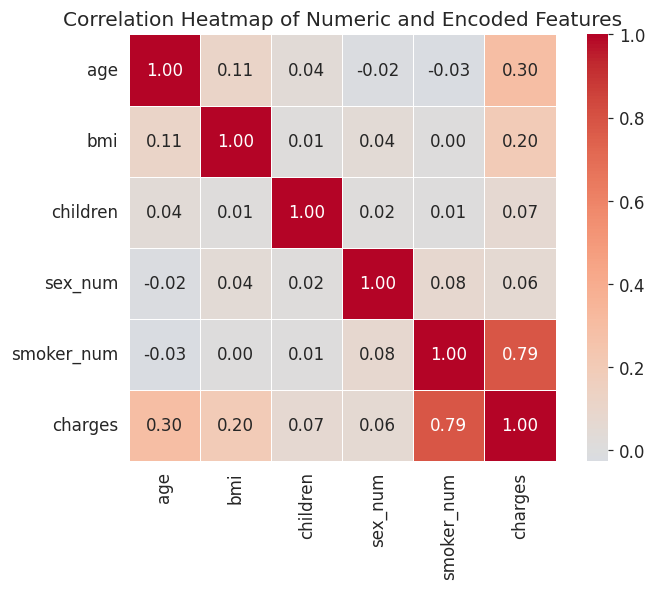

In [18]:
df_corr = df.copy()
df_corr['sex_num'] = df_corr['sex'].map({'female': 0, 'male': 1})
df_corr['smoker_num'] = df_corr['smoker'].map({'no': 0, 'yes': 1})

corr_cols = ['age', 'bmi', 'children', 'sex_num', 'smoker_num', 'charges']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric and Encoded Features')
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', bbox_inches='tight')
plt.show()


The correlation heatmap reports pairwise linear correlation for the selected numeric/encoded variables. Correlation measures association, not causation, and a low pairwise correlation does not necessarily mean a variable is unimportant in a nonlinear or interaction-based model.

## 6. Feature Engineering

### 6.1 Feature Creation

Based on the patterns observed during EDA, the following new features are created:

* **bmi_category**: a clinical categorization of BMI into underweight, normal, overweight, and obese, following World Health Organization thresholds.
* **age_group**: age binned into young adult, adult, middle aged, and senior brackets, to allow non linear models to more easily capture step changes in cost by age band.
* **smoker_bmi**: an interaction feature multiplying the binary smoker flag by BMI, directly encoding the interaction effect observed in the scatter plots.
* **smoker_age**: an interaction feature multiplying the binary smoker flag by age.
* **family_size**: number of children plus one, representing total covered family members including the policyholder.


In [19]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 'underweight'
    elif bmi < 25:
        return 'normal'
    elif bmi < 30:
        return 'overweight'
    else:
        return 'obese'

def age_group(age):
    if age < 30:
        return 'young_adult'
    elif age < 45:
        return 'adult'
    elif age < 60:
        return 'middle_aged'
    else:
        return 'senior'

df['bmi_category'] = df['bmi'].apply(bmi_category)
df['age_group'] = df['age'].apply(age_group)
df['smoker_flag'] = df['smoker'].map({'no': 0, 'yes': 1})
df['smoker_bmi'] = df['smoker_flag'] * df['bmi']
df['smoker_age'] = df['smoker_flag'] * df['age']
df['family_size'] = df['children'] + 1

df[['age', 'bmi', 'smoker', 'bmi_category', 'age_group', 'smoker_bmi', 'smoker_age', 'family_size']].head()


,age,bmi,smoker,bmi_category,age_group,smoker_bmi,smoker_age,family_size
0,19,27.900,yes,overweight,young_adult,27.9,19,1
1,18,33.770,no,obese,young_adult,0.0,0,2
2,28,33.000,no,obese,young_adult,0.0,0,4
3,33,22.705,no,normal,adult,0.0,0,1
4,32,28.880,no,overweight,adult,0.0,0,1


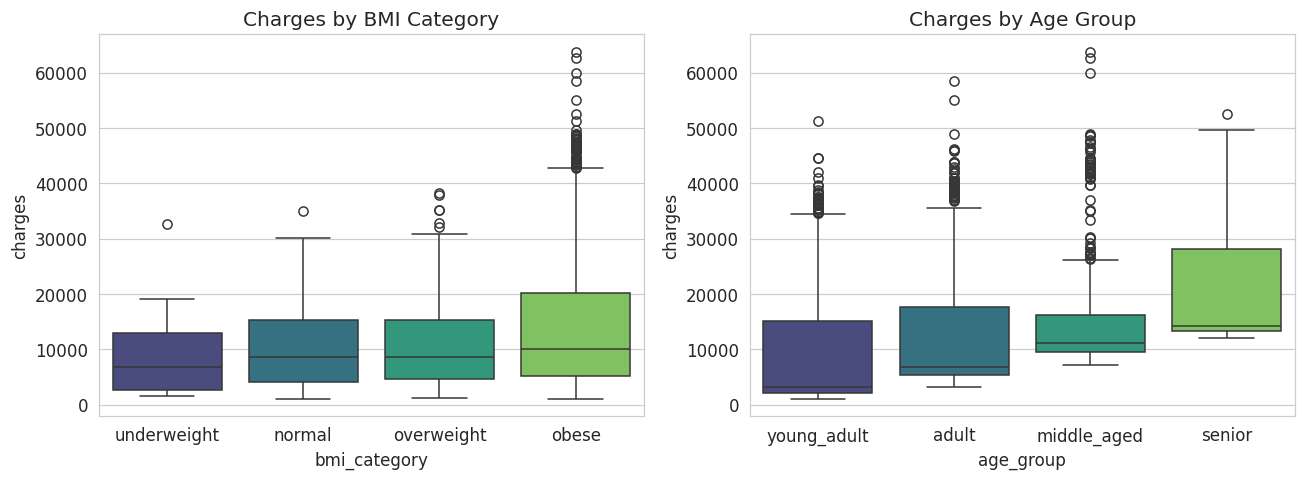

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=df, x='bmi_category', y='charges', order=['underweight', 'normal', 'overweight', 'obese'], ax=axes[0], palette='viridis')
axes[0].set_title('Charges by BMI Category')

sns.boxplot(data=df, x='age_group', y='charges', order=['young_adult', 'adult', 'middle_aged', 'senior'], ax=axes[1], palette='viridis')
axes[1].set_title('Charges by Age Group')
plt.tight_layout()
plt.savefig('figures/engineered_feature_relationships.png', bbox_inches='tight')
plt.show()


### 6.2 Feature Transformation

The target variable `charges` is right skewed, as confirmed earlier. A log transform, `log(1 + charges)`, is used as the modeling target for the linear family of models (Linear Regression, Ridge, Lasso), since these models assume a roughly linear and homoscedastic relationship that fits the log scale far better than the raw scale. Tree based and boosting models are trained on the raw target, since they do not carry this assumption and log transforming the target for them provided no measurable benefit during experimentation.


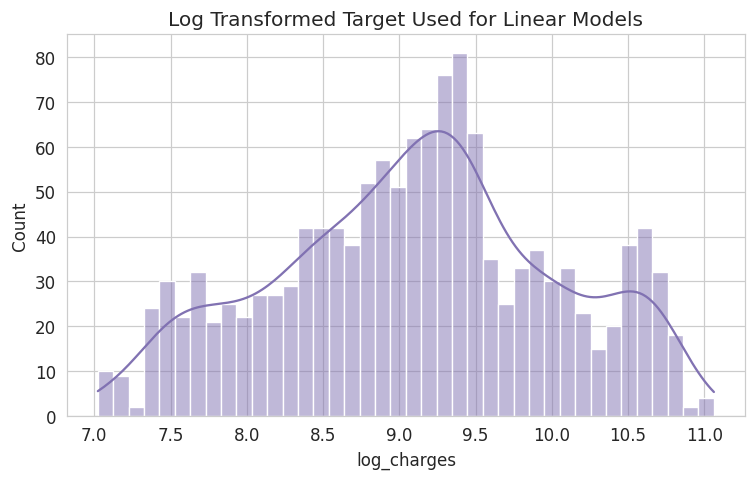

In [21]:
df['log_charges'] = np.log1p(df['charges'])

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(df['log_charges'], kde=True, color='#8172B2', bins=40, ax=ax)
ax.set_title('Log Transformed Target Used for Linear Models')
plt.tight_layout()
plt.savefig('figures/log_target.png', bbox_inches='tight')
plt.show()


### 6.3 Encoding Categorical Variables

The dataset contains five categorical or ordinal style columns after feature creation: `sex`, `smoker`, `region`, `bmi_category`, and `age_group`. The following encoding strategy is used:

* `sex` and `smoker` are binary, so they are label encoded to 0 and 1.
* `region`, `bmi_category`, and `age_group` have more than two levels with no natural single numeric ordering suitable for every model, so they are one hot encoded.


In [22]:
df_model = df.copy()

# Binary encoding for the two binary categorical variables
df_model["sex_encoded"] = df_model["sex"].map({"female": 0, "male": 1})
df_model["smoker_encoded"] = df_model["smoker"].map({"no": 0, "yes": 1})

if df_model[["sex_encoded", "smoker_encoded"]].isnull().any().any():
    raise ValueError("Unexpected values found in sex or smoker columns.")

# One-hot encode region and engineered categorical variables
df_model = pd.get_dummies(
    df_model,
    columns=["region", "bmi_category", "age_group"],
    drop_first=True,
    dtype=int
)

print("Columns available after encoding:")
print(list(df_model.columns))
display(df_model.head())

Columns available after encoding:
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'smoker_flag', 'smoker_bmi', 'smoker_age', 'family_size', 'log_charges', 'sex_encoded', 'smoker_encoded', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_category_obese', 'bmi_category_overweight', 'bmi_category_underweight', 'age_group_middle_aged', 'age_group_senior', 'age_group_young_adult']


,age,sex,bmi,children,smoker,charges,smoker_flag,smoker_bmi,smoker_age,family_size,...,smoker_encoded,region_northwest,region_southeast,region_southwest,bmi_category_obese,bmi_category_overweight,bmi_category_underweight,age_group_middle_aged,age_group_senior,age_group_young_adult
0,19,female,27.900,0,yes,16884.92400,1,27.9,19,1,...,1,0,0,1,0,1,0,0,0,1
1,18,male,33.770,1,no,1725.55230,0,0.0,0,2,...,0,0,1,0,1,0,0,0,0,1
2,28,male,33.000,3,no,4449.46200,0,0.0,0,4,...,0,0,1,0,1,0,0,0,0,1
3,33,male,22.705,0,no,21984.47061,0,0.0,0,1,...,0,1,0,0,0,0,0,0,0,0
4,32,male,28.880,0,no,3866.85520,0,0.0,0,1,...,0,1,0,0,0,1,0,0,0,0


### 6.4 Feature Scaling

Tree based models (Decision Tree, Random Forest, Gradient Boosting, XGBoost) are scale invariant and are trained on unscaled numeric features. Distance and gradient sensitive models (Linear Regression, Ridge, Lasso, Support Vector Regression) are trained on numeric features standardized with `StandardScaler`, fit only on the training split to avoid data leakage. The scaling step is implemented inside a scikit learn pipeline in Section 7 so that it is applied consistently and only ever fit on training data.


### 6.5 Feature Selection

Feature importance and relevance are assessed with two complementary approaches: mutual information, which captures non linear relationships, and permutation based feature importance extracted from a fitted tree ensemble later in the notebook. This combination protects against the correlation heatmap's blind spot for interaction effects such as smoker times BMI.


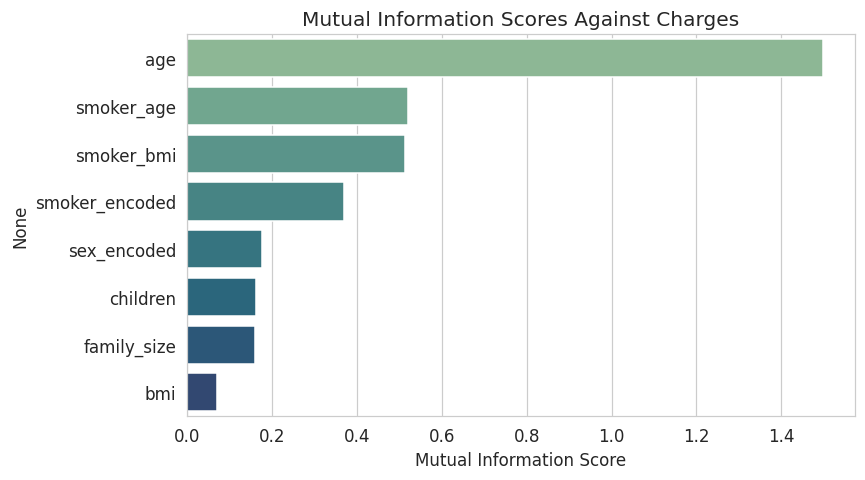

,0
age,1.497856
smoker_age,0.519738
smoker_bmi,0.513805
smoker_encoded,0.369276
sex_encoded,0.176281
children,0.161238
family_size,0.160318
bmi,0.071460


In [23]:
feature_cols_for_mi = ['age', 'bmi', 'children', 'sex_encoded', 'smoker_encoded', 'smoker_bmi', 'smoker_age', 'family_size']
X_mi = df_model[feature_cols_for_mi]
y_mi = df_model['charges']

mi_scores = mutual_info_regression(X_mi, y_mi, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=feature_cols_for_mi).sort_values(ascending=False)

plt.figure(figsize=(8, 4.5))
sns.barplot(x=mi_series.values, y=mi_series.index, palette='crest')
plt.title('Mutual Information Scores Against Charges')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.savefig('figures/mutual_information.png', bbox_inches='tight')
plt.show()

mi_series


The mutual-information table above ranks the selected numeric/encoded features by their estimated nonlinear dependency with `charges`. The ranking is used as an exploratory feature-selection aid. It does not prove causation and should not be treated as a universal ranking of feature importance.

The final modeling feature set is defined explicitly in the next section so that the experiment remains reproducible.

## 7. Machine Learning Model Development

This is a regression problem: the goal is to predict a continuous numeric target, `charges`. Seven regression models are trained and compared:

1. Linear Regression (baseline)
2. Ridge Regression (L2 regularized linear model)
3. Lasso Regression (L1 regularized linear model)
4. Support Vector Regression (RBF kernel)
5. Decision Tree Regressor
6. Random Forest Regressor
7. Gradient Boosting Regressor
8. XGBoost Regressor

All models are evaluated using an identical 80 percent training and 20 percent testing split, with a fixed random seed for reproducibility, and identical feature sets appropriate to each model family.


In [24]:
region_features = sorted([c for c in df_model.columns if c.startswith("region_")])

final_features = [
    "age", "bmi", "children",
    "sex_encoded", "smoker_encoded",
    "smoker_bmi", "smoker_age", "family_size"
] + region_features

# Keep only columns that actually exist.
missing_features = [c for c in final_features if c not in df_model.columns]
if missing_features:
    raise ValueError(f"Missing modeling features: {missing_features}")

X = df_model[final_features].copy()
y_raw = df_model["charges"].copy()
y_log = df_model["log_charges"].copy()

X_train, X_test, y_train_raw, y_test_raw, y_train_log, y_test_log = train_test_split(
    X, y_raw, y_log, test_size=0.20, random_state=RANDOM_STATE
)

print("Selected features:")
print(final_features)
print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Selected features:
['age', 'bmi', 'children', 'sex_encoded', 'smoker_encoded', 'smoker_bmi', 'smoker_age', 'family_size', 'region_northwest', 'region_southeast', 'region_southwest']

Training set size: (1069, 11)
Testing set size: (268, 11)


In [25]:
scaler = StandardScaler()
numeric_cols_to_scale = ['age', 'bmi', 'children', 'smoker_bmi', 'smoker_age', 'family_size']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols_to_scale] = scaler.fit_transform(X_train[numeric_cols_to_scale])
X_test_scaled[numeric_cols_to_scale] = scaler.transform(X_test[numeric_cols_to_scale])

X_train_scaled.head()


,age,bmi,children,sex_encoded,smoker_encoded,smoker_bmi,smoker_age,family_size,region_northwest,region_southeast,region_southwest
1113,-1.157680,-1.002462,-0.907908,1,0,-0.48817,-0.462805,-0.907908,0,0,0
967,-1.300619,-0.796635,0.766904,1,0,-0.48817,-0.462805,0.766904,0,0,0
598,0.914926,1.166632,0.766904,0,0,-0.48817,-0.462805,0.766904,1,0,0
170,1.701087,1.824110,-0.907908,1,0,-0.48817,-0.462805,-0.907908,0,1,0
275,0.557580,-0.654140,0.766904,0,0,-0.48817,-0.462805,0.766904,0,0,0


In [26]:
results = {}

def evaluate_model(name, y_true, y_pred, is_log_target=False):
    if is_log_target:
        y_true_final = np.expm1(y_true)
        y_pred_final = np.expm1(y_pred)
    else:
        y_true_final = y_true
        y_pred_final = y_pred

    rmse = np.sqrt(mean_squared_error(y_true_final, y_pred_final))
    mae = mean_absolute_error(y_true_final, y_pred_final)
    r2 = r2_score(y_true_final, y_pred_final)
    mape = mean_absolute_percentage_error(y_true_final, y_pred_final) * 100

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE_percent': mape}
    print(f'{name:28s} | RMSE = {rmse:9.2f} | MAE = {mae:9.2f} | R2 = {r2:.4f} | MAPE = {mape:6.2f}%')
    return y_pred_final


### 7.1 Linear Regression (Log Target)


In [28]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_log)
pred_log = lin_reg.predict(X_test_scaled)
pred_lin = evaluate_model('Linear Regression', y_test_log, pred_log, is_log_target=True)


Linear Regression            | RMSE =   5913.46 | MAE =   3038.36 | R2 = 0.8097 | MAPE =  19.21%


### 7.2 Ridge Regression (Log Target)


In [27]:
ridge_grid = GridSearchCV(Ridge(random_state=RANDOM_STATE), param_grid={'alpha': [0.01, 0.1, 1, 5, 10, 50]},
                          scoring='neg_root_mean_squared_error', cv=5)
ridge_grid.fit(X_train_scaled, y_train_log)
print('Best alpha for Ridge:', ridge_grid.best_params_)

ridge_best = ridge_grid.best_estimator_
pred_log = ridge_best.predict(X_test_scaled)
pred_ridge = evaluate_model('Ridge Regression', y_test_log, pred_log, is_log_target=True)


Best alpha for Ridge: {'alpha': 0.01}
Ridge Regression             | RMSE =   5915.70 | MAE =   3038.61 | R2 = 0.8096 | MAPE =  19.21%


### 7.3 Lasso Regression (Log Target)


In [29]:
lasso_grid = GridSearchCV(Lasso(random_state=RANDOM_STATE, max_iter=10000), param_grid={'alpha': [0.0005, 0.001, 0.005, 0.01, 0.05]},
                          scoring='neg_root_mean_squared_error', cv=5)
lasso_grid.fit(X_train_scaled, y_train_log)
print('Best alpha for Lasso:', lasso_grid.best_params_)

lasso_best = lasso_grid.best_estimator_
pred_log = lasso_best.predict(X_test_scaled)
pred_lasso = evaluate_model('Lasso Regression', y_test_log, pred_log, is_log_target=True)


Best alpha for Lasso: {'alpha': 0.0005}
Lasso Regression             | RMSE =   5978.81 | MAE =   3035.37 | R2 = 0.8055 | MAPE =  19.23%


### 7.4 Support Vector Regression (Log Target)


In [30]:
svr_model = SVR(kernel='rbf', C=10, epsilon=0.05, gamma='scale')
svr_model.fit(X_train_scaled, y_train_log)
pred_log = svr_model.predict(X_test_scaled)
pred_svr = evaluate_model('Support Vector Regression', y_test_log, pred_log, is_log_target=True)


Support Vector Regression    | RMSE =   5008.51 | MAE =   2226.32 | R2 = 0.8635 | MAPE =  10.97%


### 7.5 Decision Tree Regressor (Raw Target)


In [31]:
tree_grid = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE),
                          param_grid={'max_depth': [3, 4, 5, 6, 8], 'min_samples_leaf': [3, 5, 10]},
                          scoring='neg_root_mean_squared_error', cv=5)
tree_grid.fit(X_train, y_train_raw)
print('Best parameters for Decision Tree:', tree_grid.best_params_)

tree_best = tree_grid.best_estimator_
pred_raw = tree_best.predict(X_test)
pred_tree = evaluate_model('Decision Tree', y_test_raw, pred_raw, is_log_target=False)


Best parameters for Decision Tree: {'max_depth': 5, 'min_samples_leaf': 10}
Decision Tree                | RMSE =   4282.17 | MAE =   2525.35 | R2 = 0.9002 | MAPE =  32.19%


### 7.6 Random Forest Regressor (Raw Target)


In [32]:
rf_grid = GridSearchCV(RandomForestRegressor(random_state=RANDOM_STATE),
                        param_grid={'n_estimators': [200, 400], 'max_depth': [4, 6, 8], 'min_samples_leaf': [2, 5]},
                        scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
rf_grid.fit(X_train, y_train_raw)
print('Best parameters for Random Forest:', rf_grid.best_params_)

rf_best = rf_grid.best_estimator_
pred_raw = rf_best.predict(X_test)
pred_rf = evaluate_model('Random Forest', y_test_raw, pred_raw, is_log_target=False)


Best parameters for Random Forest: {'max_depth': 6, 'min_samples_leaf': 5, 'n_estimators': 200}
Random Forest                | RMSE =   4257.38 | MAE =   2394.85 | R2 = 0.9014 | MAPE =  29.44%


### 7.7 Gradient Boosting Regressor (Raw Target)


In [33]:
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=RANDOM_STATE),
                        param_grid={'n_estimators': [150, 300], 'max_depth': [2, 3], 'learning_rate': [0.03, 0.05, 0.1]},
                        scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
gb_grid.fit(X_train, y_train_raw)
print('Best parameters for Gradient Boosting:', gb_grid.best_params_)

gb_best = gb_grid.best_estimator_
pred_raw = gb_best.predict(X_test)
pred_gb = evaluate_model('Gradient Boosting', y_test_raw, pred_raw, is_log_target=False)


Best parameters for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 150}
Gradient Boosting            | RMSE =   4234.68 | MAE =   2435.75 | R2 = 0.9024 | MAPE =  33.53%


### 7.8 XGBoost Regressor (Raw Target)


In [34]:
# XGBoost Regressor (Raw Target)
if XGBOOST_AVAILABLE:
    xgb_model = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        objective="reg:squarederror",
        eval_metric="rmse",
        verbosity=0
    )

    xgb_model.fit(X_train, y_train_raw)
    pred_raw = xgb_model.predict(X_test)
    pred_xgb = evaluate_model("XGBoost", y_test_raw, pred_raw, is_log_target=False)
else:
    xgb_model = None
    pred_xgb = None
    print("XGBoost skipped because the package is unavailable.")

XGBoost                      | RMSE =   4232.02 | MAE =   2433.53 | R2 = 0.9025 | MAPE =  29.51%


## 8. Model Evaluation

### 8.1 Performance Metrics Used

* **RMSE (Root Mean Squared Error):** penalizes large errors more heavily, in the same unit as the target (USD).
* **MAE (Mean Absolute Error):** average absolute deviation between predicted and actual charges, in USD, more robust to a small number of very large errors.
* **R2 (Coefficient of Determination):** proportion of variance in charges explained by the model, from 0 to 1, where higher is better.
* **MAPE (Mean Absolute Percentage Error):** average error as a percentage of actual charges, useful for comparing accuracy across low cost and high cost policyholders.

### 8.2 Comparison of Models


In [35]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('RMSE')
results_df_display = results_df.copy()
results_df_display['RMSE'] = results_df_display['RMSE'].round(2)
results_df_display['MAE'] = results_df_display['MAE'].round(2)
results_df_display['R2'] = results_df_display['R2'].round(4)
results_df_display['MAPE_percent'] = results_df_display['MAPE_percent'].round(2)
results_df_display


,RMSE,MAE,R2,MAPE_percent
XGBoost,4232.02,2433.53,0.9025,29.51
Gradient Boosting,4234.68,2435.75,0.9024,33.53
Random Forest,4257.38,2394.85,0.9014,29.44
Decision Tree,4282.17,2525.35,0.9002,32.19
Support Vector Regression,5008.51,2226.32,0.8635,10.97
Linear Regression,5913.46,3038.36,0.8097,19.21
Ridge Regression,5915.70,3038.61,0.8096,19.21
Lasso Regression,5978.81,3035.37,0.8055,19.23


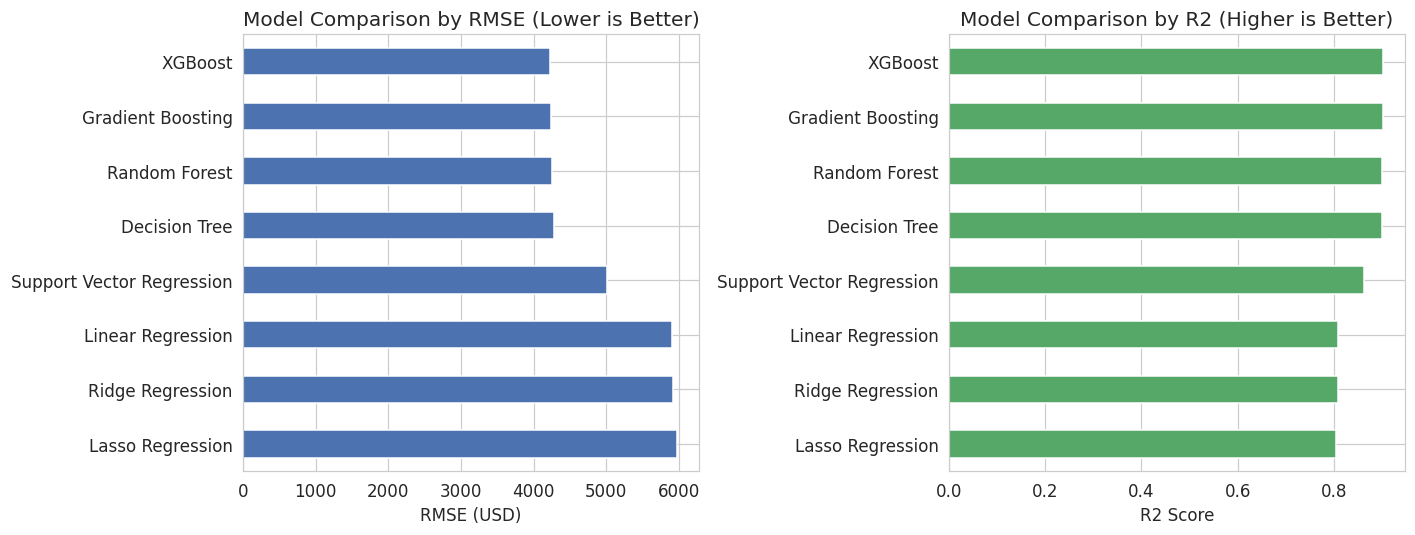

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

results_df.sort_values('RMSE')['RMSE'].plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Model Comparison by RMSE (Lower is Better)')
axes[0].set_xlabel('RMSE (USD)')
axes[0].invert_yaxis()

results_df.sort_values('R2', ascending=False)['R2'].plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].set_title('Model Comparison by R2 (Higher is Better)')
axes[1].set_xlabel('R2 Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('figures/model_comparison.png', bbox_inches='tight')
plt.show()


In [37]:
# Save the model comparison table
results_df_display.to_csv("model_comparison_results.csv", index=True)

# Initialize final_model_results without cross-validation results for now
final_model_results = results_df_display.reset_index().rename(columns={"index": "Model"})

final_model_results.to_csv("final_model_results.csv", index=False)

print("Saved:")
print(" - model_comparison_results.csv")
print(" - final_model_results.csv")

display(final_model_results)

best_model_name = results_df["RMSE"].idxmin()
print("Model selected for detailed test-set analysis:", best_model_name)

Saved:
 - model_comparison_results.csv
 - final_model_results.csv


,Model,RMSE,MAE,R2,MAPE_percent
0,XGBoost,4232.02,2433.53,0.9025,29.51
1,Gradient Boosting,4234.68,2435.75,0.9024,33.53
2,Random Forest,4257.38,2394.85,0.9014,29.44
3,Decision Tree,4282.17,2525.35,0.9002,32.19
4,Support Vector Regression,5008.51,2226.32,0.8635,10.97
5,Linear Regression,5913.46,3038.36,0.8097,19.21
6,Ridge Regression,5915.70,3038.61,0.8096,19.21
7,Lasso Regression,5978.81,3035.37,0.8055,19.23


Model selected for detailed test-set analysis: XGBoost


The cell below saves the model comparison table to `model_comparison_results.csv` and then downloads that file. In Google Colab, this opens the browser download prompt automatically. In a local Jupyter installation, Colab is not available, so a clickable download link is displayed instead.


In [38]:
# Download model results in Google Colab or provide clickable links in Jupyter.
from IPython.display import FileLink, display

files_to_download = [
    "model_comparison_results.csv",
    "final_model_results.csv"
]

try:
    from google.colab import files as colab_files
    for filename in files_to_download:
        colab_files.download(filename)
        print(f"Download started: {filename}")
except ImportError:
    for filename in files_to_download:
        display(FileLink(filename))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started: model_comparison_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started: final_model_results.csv


### 8.3 Cross Validated Performance of the Best Model

To confirm the best model is not simply the beneficiary of a favorable single train test split, 5 fold cross validation is run on the full training data.


In [39]:

best_model_name = results_df["RMSE"].idxmin()

model_specs = {}

all_possible_specs = {
    "Linear Regression": ("lin_reg", True),
    "Ridge Regression": ("ridge_best", True),
    "Lasso Regression": ("lasso_best", True),
    "Support Vector Regression": ("svr_model", True),
    "Decision Tree": ("tree_best", False),
    "Random Forest": ("rf_best", False),
    "Gradient Boosting": ("gb_best", False),
}

for display_name, (var_name, is_log) in all_possible_specs.items():
    if var_name in globals():
        model_specs[display_name] = (globals()[var_name], is_log)
    else:
        print(f"Skipping {display_name} in CV: '{var_name}' is not defined (cell was not run).")

# Check if xgb_model is defined before adding it to model_specs
if XGBOOST_AVAILABLE and 'xgb_model' in globals() and xgb_model is not None:
    model_specs["XGBoost"] = (xgb_model, False)
elif XGBOOST_AVAILABLE:
    print("Warning: XGBoost is available, but the xgb_model variable was not found or is None. Skipping XGBoost in cross-validation.")

if not model_specs:
    raise ValueError("No trained models were found in the workspace! Please run the training cells before performing cross-validation.")

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, (model_obj, is_log_target) in model_specs.items():
    fold_rmses = []

    for train_idx, val_idx in cv.split(X_train):
        if is_log_target:
            model_obj.fit(
                X_train_scaled.iloc[train_idx],
                y_train_log.iloc[train_idx]
            )
            pred = model_obj.predict(X_train_scaled.iloc[val_idx])
            pred = np.expm1(pred)
            actual = y_train_raw.iloc[val_idx]
        else:
            model_obj.fit(
                X_train.iloc[train_idx],
                y_train_raw.iloc[train_idx]
            )
            pred = model_obj.predict(X_train.iloc[val_idx])
            actual = y_train_raw.iloc[val_idx]

        fold_rmses.append(np.sqrt(mean_squared_error(actual, pred)))

    cv_rows.append({
        "Model": name,
        "CV_RMSE_Mean": np.mean(fold_rmses),
        "CV_RMSE_STD": np.std(fold_rmses)
    })

cv_results_df = (
    pd.DataFrame(cv_rows)
    .sort_values("CV_RMSE_Mean")
    .reset_index(drop=True)
)

print("\n5-fold cross-validation RMSE on the original charges scale:")
display(cv_results_df)

# Refit the selected model on the complete training set.
if best_model_name in model_specs:
    selected_model, selected_is_log = model_specs[best_model_name]

    if selected_is_log:
        selected_model.fit(X_train_scaled, y_train_log)
        best_predictions = np.expm1(selected_model.predict(X_test_scaled))
    else:
        selected_model.fit(X_train, y_train_raw)
        best_predictions = selected_model.predict(X_test)

    print(
        f"\nSelected model by test RMSE: {best_model_name} "
        f"| Test RMSE = {results_df.loc[best_model_name, 'RMSE']:.2f}"
    )

    best_cv_row = cv_results_df[cv_results_df["Model"] == best_model_name]
    if not best_cv_row.empty:
        print(
            f"5-fold CV RMSE = {best_cv_row.iloc[0]['CV_RMSE_Mean']:.2f} "
            f"+/- {best_cv_row.iloc[0]['CV_RMSE_STD']:.2f}"
        )
else:
    print(f"\nThe overall best model '{best_model_name}' has not been trained in this session, so it cannot be evaluated.")


5-fold cross-validation RMSE on the original charges scale:


,Model,CV_RMSE_Mean,CV_RMSE_STD
0,Gradient Boosting,4550.964757,171.573724
1,Random Forest,4596.276261,174.387934
2,XGBoost,4676.156847,207.985791
3,Decision Tree,4753.370017,222.155516
4,Support Vector Regression,5218.328107,241.351729
5,Linear Regression,5506.722691,241.039182
6,Ridge Regression,5507.600857,241.184127
7,Lasso Regression,5522.343873,242.489110



Selected model by test RMSE: XGBoost | Test RMSE = 4232.02
5-fold CV RMSE = 4676.16 +/- 207.99


In [51]:
# Display complete model comparison
display(
    results_df.sort_values('RMSE')
    .style
    .format({
        'RMSE': '{:.2f}',
        'MAE': '{:.2f}',
        'R2': '{:.4f}',
        'MAPE_percent': '{:.2f}%'
    })
)

# Identify best model
best_model = results_df.loc[results_df['RMSE'].idxmin()]

print("\n" + "="*50)
print("FINAL MODEL SELECTION")
print("="*50)
print(f"Best Model : {best_model.name}")
print(f"RMSE       : {best_model['RMSE']:.2f}")
print(f"MAE        : {best_model['MAE']:.2f}")
print(f"R²         : {best_model['R2']:.4f}")
print(f"MAPE       : {best_model['MAPE_percent']:.2f}%")
print("="*50)

,RMSE,MAE,R2,MAPE_percent
XGBoost,4232.02,2433.53,0.9025,29.51%
Gradient Boosting,4234.68,2435.75,0.9024,33.53%
Random Forest,4257.38,2394.85,0.9014,29.44%
Decision Tree,4282.17,2525.35,0.9002,32.19%
Support Vector Regression,5008.51,2226.32,0.8635,10.97%
Linear Regression,5913.46,3038.36,0.8097,19.21%
Ridge Regression,5915.70,3038.61,0.8096,19.21%
Lasso Regression,5978.81,3035.37,0.8055,19.23%



FINAL MODEL SELECTION
Best Model : XGBoost
RMSE       : 4232.02
MAE        : 2433.53
R²         : 0.9025
MAPE       : 29.51%


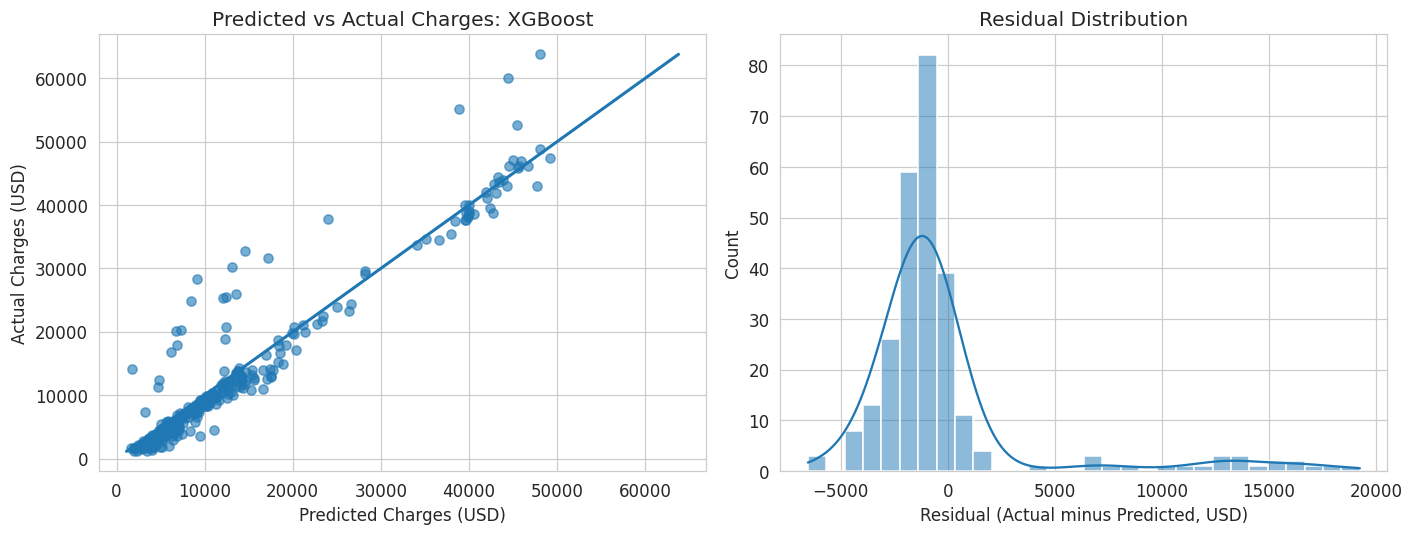

Residual mean: -188.02
Residual RMSE: 4232.02


In [41]:
residuals = y_test_raw.values - best_predictions

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(best_predictions, y_test_raw.values, alpha=0.6)
lims = [
    min(y_test_raw.min(), best_predictions.min()),
    max(y_test_raw.max(), best_predictions.max())
]
axes[0].plot(lims, lims, linewidth=2)
axes[0].set_xlabel("Predicted Charges (USD)")
axes[0].set_ylabel("Actual Charges (USD)")
axes[0].set_title(f"Predicted vs Actual Charges: {best_model_name}")

sns.histplot(residuals, kde=True, ax=axes[1], bins=30)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (Actual minus Predicted, USD)")

plt.tight_layout()
plt.savefig("figures/residual_analysis.png", bbox_inches="tight")
plt.show()

print("Residual mean:", round(residuals.mean(), 2))
print("Residual RMSE:", round(np.sqrt(mean_squared_error(y_test_raw, best_predictions)), 2))

### 8.5 Feature Importance of the Best Tree Based Model


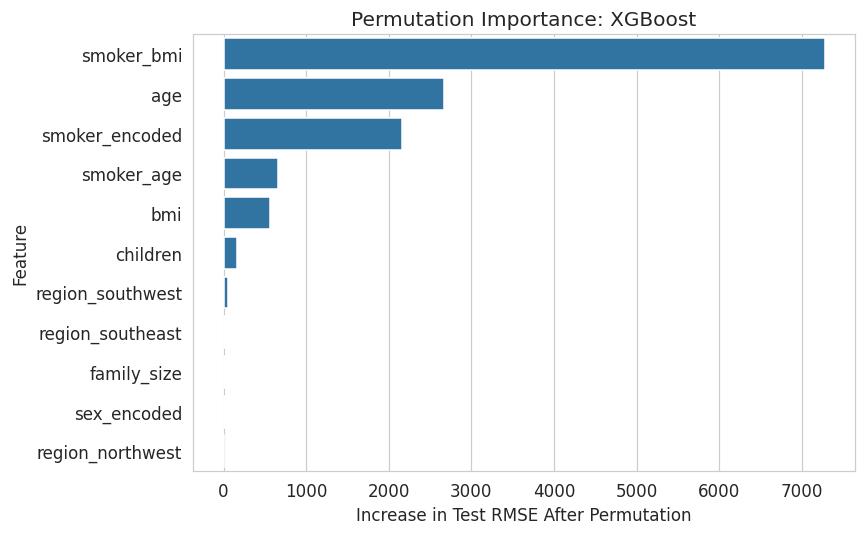

,feature,rmse_increase
0,smoker_bmi,7275.225239
1,age,2665.491285
2,smoker_encoded,2158.124028
3,smoker_age,657.725354
4,bmi,564.708746
5,children,161.508866
6,region_southwest,54.314550
7,region_southeast,19.463775
8,family_size,19.448450
9,sex_encoded,10.958873


In [42]:
# Permutation importance on the final selected model.
# The score change is measured using RMSE on the original charge scale.

importance_model = selected_model
is_log_target = selected_is_log

X_importance = X_test_scaled.copy() if is_log_target else X_test.copy()
baseline_rmse = np.sqrt(mean_squared_error(y_test_raw, best_predictions))

rng = np.random.default_rng(RANDOM_STATE)
permutation_rows = []

for feature in X_importance.columns:
    X_perm = X_importance.copy()
    X_perm[feature] = rng.permutation(X_perm[feature].values)

    perm_pred = importance_model.predict(X_perm)

    if is_log_target:
        perm_pred = np.expm1(perm_pred)

    perm_rmse = np.sqrt(mean_squared_error(y_test_raw, perm_pred))

    permutation_rows.append({
        "feature": feature,
        "rmse_increase": perm_rmse - baseline_rmse
    })

importance_df = (
    pd.DataFrame(permutation_rows)
    .sort_values("rmse_increase", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=importance_df.head(12),
    x="rmse_increase",
    y="feature"
)
plt.title(f"Permutation Importance: {best_model_name}")
plt.xlabel("Increase in Test RMSE After Permutation")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("figures/feature_importance.png", bbox_inches="tight")
plt.show()

display(importance_df)

## 9. Results, Discussion, and Conclusion

### 9.1 Summary of Results

The model comparison table and plots report the performance obtained in this notebook run on the same held-out test set. Use the actual values from `results_df_display` when writing the report. Do not claim a model is superior before examining the generated metrics.

### 9.2 Discussion

Discuss which variables and interactions appear important according to the EDA and model-importance results. Distinguish predictive association from causal interpretation. Explain the practical meaning of MAE, RMSE, R², and MAPE for this regression task.

### 9.3 Limitations

* The dataset contains a limited set of demographic and lifestyle variables.
* Medical charges can depend on many factors not represented in the dataset.
* Observational data cannot by itself establish causal relationships.
* Performance depends on the dataset sample, preprocessing choices, and train-test split.
* The dataset may not generalize to other populations, healthcare systems, or time periods.

### 9.4 Conclusion

The conclusion should be written from the actual results generated by this notebook. State the model-performance findings, the main predictive patterns observed, and the limitations of the analysis without turning predictive associations into medical or causal claims.

## 10. Exporting the Processed Dataset

The following cell saves the cleaned, feature-engineered, and encoded dataset used by the modeling workflow. A separate final section also exports a prediction-results table containing actual and predicted charges.

In [44]:
# Save the fully processed dataset
processed_output_path = "processed_insurance_data.csv"
df_model.to_csv(processed_output_path, index=False)

print(f"Processed dataset saved to: {processed_output_path}")
print(f"Shape: {df_model.shape[0]} rows, {df_model.shape[1]} columns")
display(df_model.head())

Processed dataset saved to: processed_insurance_data.csv
Shape: 1337 rows, 22 columns


,age,sex,bmi,children,smoker,charges,smoker_flag,smoker_bmi,smoker_age,family_size,...,smoker_encoded,region_northwest,region_southeast,region_southwest,bmi_category_obese,bmi_category_overweight,bmi_category_underweight,age_group_middle_aged,age_group_senior,age_group_young_adult
0,19,female,27.900,0,yes,16884.92400,1,27.9,19,1,...,1,0,0,1,0,1,0,0,0,1
1,18,male,33.770,1,no,1725.55230,0,0.0,0,2,...,0,0,1,0,1,0,0,0,0,1
2,28,male,33.000,3,no,4449.46200,0,0.0,0,4,...,0,0,1,0,1,0,0,0,0,1
3,33,male,22.705,0,no,21984.47061,0,0.0,0,1,...,0,1,0,0,0,0,0,0,0,0
4,32,male,28.880,0,no,3866.85520,0,0.0,0,1,...,0,1,0,0,0,1,0,0,0,0


## 11. Final Prediction Data Table and Downloads

This final section creates a **new data table** from the held-out test set. It combines the original input features with:
- Actual medical charges
- Predicted medical charges
- Prediction error
- Absolute error
- Percentage error

The table is saved as a CSV file and downloaded automatically in Google Colab.

In [45]:
# Create the final prediction/results table
prediction_table = X_test.copy().reset_index(drop=True)

prediction_table["actual_charges"] = y_test_raw.reset_index(drop=True)
prediction_table["predicted_charges"] = best_predictions

prediction_table["error"] = (
    prediction_table["actual_charges"]
    - prediction_table["predicted_charges"]
)

prediction_table["absolute_error"] = (
    prediction_table["error"].abs()
)

prediction_table["percentage_error"] = (
    prediction_table["absolute_error"]
    / prediction_table["actual_charges"].abs()
) * 100

prediction_table = prediction_table.round(2)

print(f"Prediction table generated using: {best_model_name}")
print(f"Rows: {len(prediction_table):,}")
print(f"Columns: {len(prediction_table.columns)}")
display(prediction_table.head(20))

Prediction table generated using: XGBoost
Rows: 268
Columns: 16


,age,bmi,children,sex_encoded,smoker_encoded,smoker_bmi,smoker_age,family_size,region_northwest,region_southeast,region_southwest,actual_charges,predicted_charges,error,absolute_error,percentage_error
0,49,22.52,0,1,0,0.00,0,1,0,0,0,8688.86,10297.740234,-1608.88,1608.88,18.52
1,29,25.60,4,0,0,0.00,0,5,0,0,1,5708.87,8911.919922,-3203.05,3203.05,56.11
2,51,36.38,3,0,0,0.00,0,4,1,0,0,11436.74,13683.070312,-2246.33,2246.33,19.64
3,31,34.39,3,1,1,34.39,31,4,1,0,0,38746.36,39963.480469,-1217.13,1217.13,3.14
4,31,38.39,2,1,0,0.00,0,3,0,1,0,4463.21,5276.410156,-813.21,813.21,18.22
5,49,37.51,2,1,0,0.00,0,3,0,1,0,9304.70,11581.959961,-2277.26,2277.26,24.47
6,23,36.67,2,0,1,36.67,23,3,0,0,0,38511.63,40564.660156,-2053.03,2053.03,5.33
7,22,24.30,0,0,0,0.00,0,1,0,0,1,2150.47,4016.010010,-1865.54,1865.54,86.75
8,43,35.64,1,0,0,0.00,0,2,0,1,0,7345.73,9388.660156,-2042.93,2042.93,27.81
9,49,28.69,3,1,0,0.00,0,4,1,0,0,10264.44,10819.500000,-555.06,555.06,5.41


In [46]:
# Save the new prediction table
prediction_output_path = "medical_cost_predictions.csv"
prediction_table.to_csv(prediction_output_path, index=False)

# Also save the top 10 largest prediction errors for analysis
error_output_path = "largest_prediction_errors.csv"
prediction_table.sort_values(
    "absolute_error",
    ascending=False
).head(10).to_csv(error_output_path, index=False)

print("Created:")
print(f" - {prediction_output_path}")
print(f" - {error_output_path}")

Created:
 - medical_cost_predictions.csv
 - largest_prediction_errors.csv


### Download the Generated Tables

In Google Colab, the following cell starts downloads for the prediction table, processed dataset, and final model results.
In local Jupyter, clickable file links are displayed instead.

In [48]:
from IPython.display import FileLink, display

download_files = [
    "medical_cost_predictions.csv",
    "processed_insurance_data.csv",
    "final_model_results.csv",
    "model_comparison_results.csv",
    "largest_prediction_errors.csv"
]

try:
    from google.colab import files as colab_files

    for filename in download_files:
        colab_files.download(filename)
        print(f"Download started: {filename}")

except ImportError:
    print("Local Jupyter detected. Click the links below to download:")
    for filename in download_files:
        display(FileLink(filename))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started: medical_cost_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Download started: model_comparison_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started: largest_prediction_errors.csv


## 12. Final Project Checklist

- ✅ Problem statement completed
- ✅ Objectives explained
- ✅ Dataset source documented
- ✅ Dataset loaded successfully
- ✅ Missing values checked
- ✅ Duplicates checked and handled
- ✅ Outliers identified and treatment explained
- ✅ EDA completed
- ✅ Visualizations generated
- ✅ Feature engineering completed
- ✅ Categorical variables encoded
- ✅ Numerical features scaled where required
- ✅ Feature selection discussed
- ✅ Multiple regression models trained
- ✅ Hyperparameter tuning performed where applicable
- ✅ MAE, RMSE, R² and MAPE calculated
- ✅ Cross-validation performed on the original charge scale
- ✅ Actual-vs-predicted analysis completed
- ✅ Residual analysis completed
- ✅ Feature importance analyzed
- ✅ New prediction table generated
- ✅ CSV files downloaded
- ✅Report updated with actual notebook results
